# Analyzing TCR data

In [1]:
# new function to setup tutorial data
from dandelion.tutorial import setup_dandelion_tutorial_tcr

setup_dandelion_tutorial_tcr()

# change to the tutorial data directory
import os

os.chdir("dandelion_tutorial")

I'm showing two examples for reading in the data: with or without reannotation.

<b>Read in AIRR format</b>

In [2]:
import dandelion as ddl

# read in the airr_rearrangement.tsv file
file1 = "sc5p_v2_hs_PBMC_10k_t/airr_rearrangement.tsv"
file2 = "sc5p_v1p1_hs_melanoma_10k_t/airr_rearrangement.tsv"

In [3]:
vdj1 = ddl.read_10x_airr(file1)
vdj1

Lazy Dandelion object with n_obs = 5351 and n_contigs = 10860
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status
    metadata: cell_id, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, locus_VDJ_

In [4]:
vdj2 = ddl.read_10x_airr(file2)
vdj2

Lazy Dandelion object with n_obs = 1560 and n_contigs = 2755
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status
    metadata: cell_id, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, locus_VDJ_m

In [5]:
# combine into a singular object
# let's add the sample_id to each cell barcode so that we don't end up overlapping later on
vdj1.add_cell_prefix("sc5p_v2_hs_PBMC_10k_t_")
vdj2.add_cell_prefix("sc5p_v1p1_hs_melanoma_10k_t_")

# combine into a singular object
vdj = ddl.tl.concat([vdj1, vdj2])
vdj

Lazy Dandelion object with n_obs = 6911 and n_contigs = 13615
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status
    metadata: cell_id, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, locus_VDJ_

<b>Read in with reannotation</b>

We specify the `filename_prefix` option because they have different prefixes that precedes `_contig.fasta` and `_contig_annotations.csv`.

In [6]:
samples = ["sc5p_v2_hs_PBMC_10k_t", "sc5p_v1p1_hs_melanoma_10k_t"]

ddl.pp.format_fastas(samples, prefix=samples, filename_prefix="filtered")

Formatting fasta(s) :   0%|          | 0/2 [00:00<?, ?it/s]

Formatting fasta(s) : 100%|██████████| 2/2 [00:01<00:00,  1.45it/s]


Make sure to toggle `loci = 'tr'` for TCR data. I'm setting `reassign_dj = True` so as to try and force a reassignment of J genes (and D genes if it can) with stricter cut offs.

In [7]:
ddl.pp.reannotate_genes(
    samples, loci="tr", reassign_dj=True, filename_prefix="filtered"
)

Assigning genes :   0%|          | 0/2 [00:00<?, ?it/s]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 12:01:13 |Done                | 0.0 min

PROGRESS> 12:01:18 |####################| 100% (13,630) 0.1 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 12252
  FAIL> 1378
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 12:01:19 |Done                | 0.0 min

PROGRESS> 12:01:23 |####################| 100% (13,630) 0.1 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 12252
  FAIL> 1378
   END> MakeDb



Assigning genes :  50%|█████     | 1/2 [02:33<02:33, 153.17s/it]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 12:02:07 |Done                | 0.0 min

PROGRESS> 12:02:09 |####################| 100% (3,706) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 3219
  FAIL> 487
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> filtered_contig_igblast.fmt7
      SEQ_FILE> filtered_contig.fasta
         NPROC> 8
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 12:02:09 |Done                | 0.0 min

PROGRESS> 12:02:11 |####################| 100% (3,706) 0.0 min

OUTPUT> filtered_contig_igblast_db-pass.tsv
  PASS> 3219
  FAIL> 487
   END> MakeDb



Assigning genes : 100%|██████████| 2/2 [03:15<00:00, 97.55s/it] 


There's no need to run the the rest of the preprocessing steps.

We'll read in the reannotated files like as follow:

In [8]:
import pandas as pd

tcr_files = []
for sample in samples:
    file_location = sample + "/dandelion/filtered_contig_dandelion.tsv"
    tcr_files.append(pd.read_csv(file_location, sep="\t"))
tcr = pd.concat(tcr_files, ignore_index=True)
tcr.reset_index(inplace=True, drop=True)
tcr

,sequence_id,sequence,rev_comp,productive,v_call,d_call,j_call,sequence_alignment,germline_alignment,junction,...,d_germline_alignment_blastn,d_call_igblastn,d_source,d_support_igblastn,d_score_igblastn,j_call_multimappers,j_call_multiplicity,j_call_sequence_start_multimappers,j_call_sequence_end_multimappers,j_call_support_multimappers
0,sc5p_v2_hs_PBMC_10k_t_AAACCTGAGCGATAGC_contig_1,CTGGAAGACCACCTGGGCTGTCATTGAGCTCTGGTGCCAGGAGGAA...,F,T,TRAV23/DV6*02,NaN,TRAJ22*01,CAGCAGCAGGTGAAACAAAGTCCTCAATCTTTGATAGTCCAGAAAG...,CAGCAGCAGGTGAAACAAAGTCCTCAATCTTTGATAGTCCAGAAAG...,TGTGCAGCAAGCAAGGGTTCTGCAAGGCAACTGACCTTT,...,NaN,NaN,NaN,NaN,NaN,"[""TRAJ22*01""]",1,[412],[466],[2.61e-25]
1,sc5p_v2_hs_PBMC_10k_t_AAACCTGAGCGATAGC_contig_2,GAGAGTCCTGCTCCCCTTTCATCAATGCACAGATACAGAAGACCCC...,F,T,TRBV6-5*01,NaN,TRBJ2-3*01,AATGCTGGTGTCACTCAGACCCCAAAATTCCAGGTCCTGAAGACAG...,AATGCTGGTGTCACTCAGACCCCAAAATTCCAGGTCCTGAAGACAG...,TGTGCCAGCAGTTACCGGGGGGGATCGGAAGATACGCAGTATTTT,...,NaN,NaN,NaN,NaN,NaN,"[""TRBJ2-3*01""]",1,[423],[466],[3.47e-19]
2,sc5p_v2_hs_PBMC_10k_t_AAACCTGAGTCACGCC_contig_2,CCTTTTCACCAATGCACAGACCCAGAGGACCCCTCCATCCTGCAGT...,F,T,"TRBV6-2*01,TRBV6-3*01",NaN,TRBJ2-6*01,AATGCTGGTGTCACTCAGACCCCAAAATTCCGGGTCCTGAAGACAG...,AATGCTGGTGTCACTCAGACCCCAAAATTCCGGGTCCTGAAGACAG...,TGTGCCAGCAGTTATCTCCCCCGTAGACAGGACAGGGAATCCTCTG...,...,NaN,NaN,NaN,NaN,NaN,"[""TRBJ2-6*01""]",1,[422],[474],[3.5e-24]
3,sc5p_v2_hs_PBMC_10k_t_AAACCTGAGTCACGCC_contig_1,GTAGCTCGTTGATATCTGTGTGGATAGGGAGCTGTGACGAGGGCAA...,F,T,TRAV8-6*02,NaN,TRAJ8*01,GCCCAGTCTGTGACCCAGCTTGACAGCCAAGTCCCTGTCTTTGAAG...,GCCCAGTCTGTGACCCAGCTTGACAGCCAAGTCCCTGTCTTTGAAG...,TGTGCTGTGAGTGCGTTTTTTCAGAAACTTGTATTT,...,NaN,NaN,NaN,NaN,NaN,"[""TRAJ8*01""]",1,[566],[614],[7.35e-22]
4,sc5p_v2_hs_PBMC_10k_t_AAACCTGCACGTCAGC_contig_1,CCCACATGAAGTGTCTACCTTCTGCAGACTCCAATGGCTCAGGAAC...,F,T,TRAV1-2*01,NaN,TRAJ33*01,GGACAAAACATTGACCAG...CCCACTGAGATGACAGCTACGGAAG...,GGACAAAACATTGACCAG...CCCACTGAGATGACAGCTACGGAAG...,TGTGCTGTCATGGATAGCAACTATCAGTTAATCTGG,...,NaN,NaN,NaN,NaN,NaN,"[""TRAJ33*01""]",1,[407],[463],[2.01e-26]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15466,sc5p_v1p1_hs_melanoma_10k_t_TTTGGTTTCACAGGCC_c...,AATGGCTCAGGAACTGGGAATGCAGTGCCAGGCTCGTGGTATCCTG...,F,T,TRAV1-2*01,NaN,TRAJ20*01,GGACAAAACATTGACCAG...CCCACTGAGATGACAGCTACGGAAG...,GGACAAAACATTGACCAG...CCCACTGAGATGACAGCTACGGAAG...,TGTGCTGTGATGGGGGACTACAAGCTCAGCTTT,...,NaN,NaN,NaN,NaN,NaN,"[""TRAJ20*01""]",1,[380],[428],[5.22e-22]
15467,sc5p_v1p1_hs_melanoma_10k_t_TTTGGTTTCTTTACGT_c...,TTCCTCTGCTCTGGCAGCAGATCTCCCAGAGGGAGCAGCCTGACCA...,F,T,TRBV30*01,NaN,TRBJ2-5*01,TCTCAGACTATTCATCAATGGCCAGCGACCCTGGTGCAGCCTGTGG...,TCTCAGACTATTCATCAATGGCCAGCGACCCTGGTGCAGCCTGTGG...,TGTGCCTGGAGTGAGCTAGCGGCCCAAGAGACCCAGTACTTC,...,NaN,NaN,NaN,NaN,NaN,"[""TRBJ2-5*01""]",1,[457],[503],[8.02e-21]
15468,sc5p_v1p1_hs_melanoma_10k_t_TTTGGTTTCTTTACGT_c...,GATCTTAATTGGGAAGAACAAGGATGACATCCATTCGAGCTGTATT...,F,F,TRAV13-1*02,NaN,TRAJ43*01,GGAGAGAATGTGGAGCAGCATCCTTCAACCCTGAGTGTCCAGGAGG...,GGAGAGAATGTGGAGCAGCATCCTTCAACCCTGAGTGTCCAGGAGG...,TGTGCAGCAAGTACAACCCGAAGGTTAGGCGGGGTGGGGTCAAAAA...,...,NaN,NaN,NaN,NaN,NaN,"[""TRAJ43*01""]",1,[388],[439],[2.49e-20]
15469,sc5p_v1p1_hs_melanoma_10k_t_TTTGTCACATTTCACT_c...,TCTGGGGATGTTCACAGAGGGCCTGGTCTGGAATATTCCACATCTG...,F,T,TRBV12-4*01,NaN,TRBJ1-1*01,GATGCTGGAGTTATCCAGTCACCCCGGCACGAGGTGACAGAGATGG...,GATGCTGGAGTTATCCAGTCACCCCGGCACGAGGTGACAGAGATGG...,TGTGCCAGCAGTTTAGGATGGGGAGACGGCACTGAAGCTTTCTTT,...,NaN,NaN,NaN,NaN,NaN,"[""TRBJ1-1*01""]",1,[419],[462],[3.45e-19]


The reannotated file can be used with dandelion as per the BCR tutorial.

For the rest of the tutorial, I'm going to show how to proceed with 10x's AIRR format file instead as there are some minor differences.

<b>Import modules for use with scanpy</b>

In [9]:
import anndata as ad
import scanpy as sc

import warnings

warnings.filterwarnings("ignore")
sc.logging.print_header()

Package,Version
pandas,2.3.3
sc-dandelion,1.0.0a1.dev36+dirty (1.0.0a1.dev36)
anndata,0.12.11
scanpy,1.11.5
Component,Info
Python,"3.12.9 | packaged by conda-forge | (main, Mar 4 2025, 22:44:42) [Clang 18.1.8 ]"
OS,macOS-26.5.2-arm64-arm-64bit
CPU,"8 logical CPU cores, arm"
GPU,No GPU found
Updated,2026-09-03 02:02


<b>Import the transcriptome data</b>

In [10]:
adata_list = []
for sample in samples:
    adata_tmp = sc.read_10x_h5(
        f"{sample}/filtered_feature_bc_matrix.h5", gex_only=True
    )
    adata_tmp.obs["sample_id"] = sample
    adata_tmp.obs_names = [sample + "_" + x for x in adata_tmp.obs_names]
    adata_tmp.var_names_make_unique()
    adata_list.append(adata_tmp)
adata = ad.concat(adata_list)
adata

AnnData object with n_obs × n_vars = 17275 × 36601
    obs: 'sample_id'

<b>Run QC on the transcriptome data.</b>

In [11]:
ddl.pp.recipe_scanpy_qc(adata)
adata

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


AnnData object with n_obs × n_vars = 17275 × 36601
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'scrublet_score', 'is_doublet', 'filter_rna'

<b>Filtering TCR data.</b>

Note that I'm using the `Dandelion` object as input rather than the pandas dataframe (yes both types of input will works. In fact, a file path to the .tsv will work too).

In [12]:
adata.obs

,sample_id,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,scrublet_score,is_doublet,filter_rna
sc5p_v2_hs_PBMC_10k_t_AAACCTGAGACAGACC-1,sc5p_v2_hs_PBMC_10k_t,1982,1982,4751.0,202.0,4.251737,0.000279,False,False
sc5p_v2_hs_PBMC_10k_t_AAACCTGAGCGATAGC-1,sc5p_v2_hs_PBMC_10k_t,1761,1761,5767.0,111.0,1.924744,0.000279,False,False
sc5p_v2_hs_PBMC_10k_t_AAACCTGAGCGGCTTC-1,sc5p_v2_hs_PBMC_10k_t,1957,1957,4991.0,125.0,2.504508,0.000279,False,False
sc5p_v2_hs_PBMC_10k_t_AAACCTGAGGATCGCA-1,sc5p_v2_hs_PBMC_10k_t,2310,2310,6012.0,222.0,3.692615,0.000279,False,False
sc5p_v2_hs_PBMC_10k_t_AAACCTGAGTCACGCC-1,sc5p_v2_hs_PBMC_10k_t,2315,2315,7267.0,158.0,2.174212,0.000279,False,False
...,...,...,...,...,...,...,...,...,...
sc5p_v1p1_hs_melanoma_10k_t_TTTGTCACATTTCACT-1,sc5p_v1p1_hs_melanoma_10k_t,1350,1350,4110.0,27.0,0.656934,0.000279,False,False
sc5p_v1p1_hs_melanoma_10k_t_TTTGTCAGTGGTAACG-1,sc5p_v1p1_hs_melanoma_10k_t,1336,1336,3663.0,60.0,1.638002,0.000279,False,False
sc5p_v1p1_hs_melanoma_10k_t_TTTGTCATCACCGTAA-1,sc5p_v1p1_hs_melanoma_10k_t,1303,1303,4366.0,163.0,3.733394,0.000279,False,False
sc5p_v1p1_hs_melanoma_10k_t_TTTGTCATCCCTTGTG-1,sc5p_v1p1_hs_melanoma_10k_t,1396,1396,3590.0,64.0,1.782730,0.000279,False,False


In [13]:
# The function will return both objects.
vdj, adata = ddl.pp.check_contigs(vdj, adata, library_type="tr-ab")

Filtering contigs...
Marking ambiguous contigs...
Initializing DandelionPolars object...


<b>Check the output V(D)J table</b>

In [14]:
vdj

Lazy Dandelion object with n_obs = 6848 and n_contigs = 13343
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status, extra, ambiguous
    metadata: cell_id, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, junction_aa_VDJ_main, junction_aa_V

<b>Check the AnnData object as well</b>

In [15]:
adata

AnnData object with n_obs × n_vars = 17275 × 36601
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ'

<b>The number of cells that actually has a matching BCR can be tabluated.</b>

In [16]:
pd.crosstab(adata.obs["has_contig"], adata.obs["chain_status"])

chain_status,Ambiguous,Extra pair,Orphan VDJ,Orphan VJ,Single pair
has_contig,,,,,
True,638,60,933,116,5101


<b>Now actually filter the AnnData object and run through a standard workflow starting by filtering genes and normalizing the data</b>

Because the 'filtered' `AnnData` object was returned as a filtered but otherwise unprocessed object, we still need to normalize and run through the usual process here. The following is just a standard scanpy workflow.

In [17]:
# standard preprocessing steps
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

... storing 'sample_id' as categorical
... storing 'is_doublet' as categorical
... storing 'filter_rna' as categorical
... storing 'has_contig' as categorical
... storing 'productive_VDJ' as categorical
... storing 'productive_VJ' as categorical
... storing 'v_call_VDJ' as categorical
... storing 'v_call_VJ' as categorical
... storing 'd_call_VDJ' as categorical
... storing 'j_call_VDJ' as categorical
... storing 'j_call_VJ' as categorical
... storing 'c_call_VDJ' as categorical
... storing 'c_call_VJ' as categorical
... storing 'junction_VDJ' as categorical
... storing 'junction_VJ' as categorical
... storing 'junction_aa_VDJ' as categorical
... storing 'junction_aa_VJ' as categorical
... storing 'locus_VDJ' as categorical
... storing 'locus_VJ' as categorical
... storing 'productive_VDJ_main' as categorical
... storing 'productive_VJ_main' as categorical
... storing 'v_call_VDJ_main' as categorical
... storing 'v_call_VJ_main' as categorical
... storing 'd_call_VDJ_main' as categoric

### Visualizing the clusters and whether or not there's a corresponding V(D)J receptor

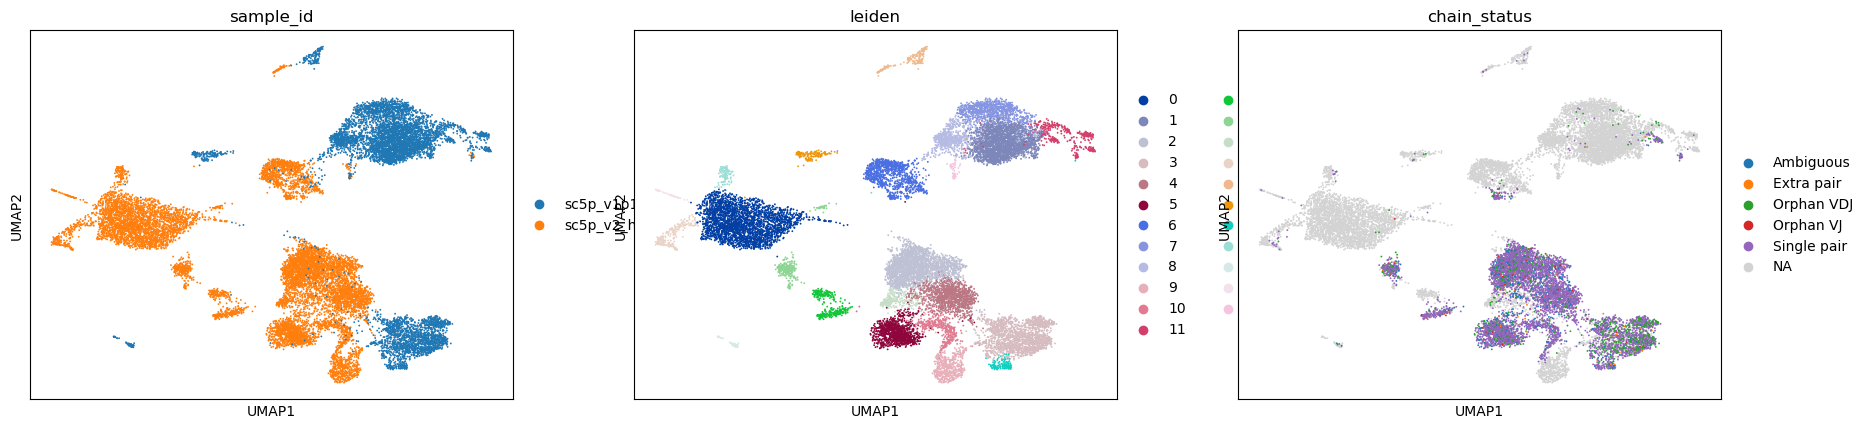

In [18]:
sc.pl.umap(adata, color=["sample_id", "leiden", "chain_status"])

### Visualizing some T cell genes

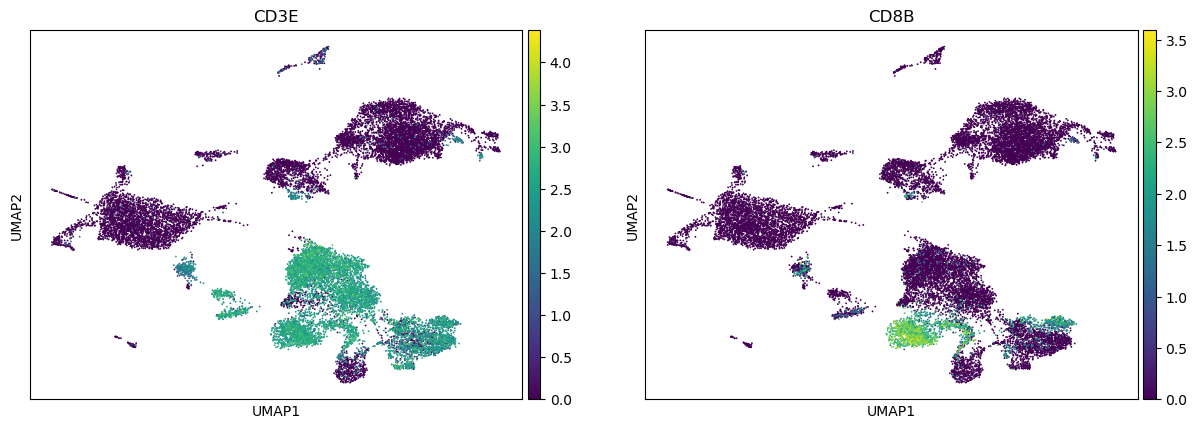

In [19]:
sc.pl.umap(adata, color=["CD3E", "CD8B"])

<b>Find clones.</b>

<div class="alert alert-info">

Note

Here we specify `identity = 1` so only cells with identical CDR3 nucleotide sequences (`key = 'junction'`) are grouped into clones/clonotypes.

</div>

In [20]:
ddl.tl.find_clones(vdj, identity=1, key="junction")
vdj

Using PyTorch backend with Apple Metal GPU


Finding clones based on abT cell VDJ chains using junction: 100%|██████████| 2289/2289 [00:02<00:00, 1023.86it/s]
Finding clones based on abT cell VJ chains using junction: 100%|██████████| 3754/3754 [00:02<00:00, 1716.22it/s]
Building distance matrix (batched): 100%|██████████| 61/61 [00:00<00:00, 3607.06it/s]


Lazy Dandelion object with n_obs = 6848 and n_contigs = 13343
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status, extra, ambiguous, clone_id
    metadata: cell_id, clone_id, clone_id_rank, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, 

<b>Generate TCR network.</b>

The 10x-provided AIRR file is missing columns like `sequence_alignment` and `sequence_alignment_aa` so we will use the next best thing, which is `sequence` or `sequence_aa`. Note that these columns are not-gapped.

Specify `key = 'sequence_aa'` to toggle this behavior. Can also try `junction` or `junction_aa` if just want to visualise the CDR3 linkage.

In [21]:
# again, i'm removing the Orphan VJ cells (lacking TRB chain i.e. VDJ information).
vdj = vdj[
    vdj.metadata.chain_status.is_in(
        ["Single pair", "Extra pair", "Extra pair-exception", "Orphan VDJ"]
    )
].copy()

In [22]:
ddl.tl.generate_network(vdj, key="sequence_aa")

In [23]:
vdj

Lazy Dandelion object with n_obs = 6094 and n_contigs = 11300
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status, extra, ambiguous, clone_id
    metadata: cell_id, clone_id, clone_id_rank, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, 

<b>Plotting in scanpy.</b>

In [24]:
ddl.tl.transfer(adata, vdj)

... storing 'productive_VDJ' as categorical
... storing 'productive_VJ' as categorical
... storing 'v_call_VDJ' as categorical
... storing 'v_call_VJ' as categorical
... storing 'd_call_VDJ' as categorical
... storing 'j_call_VDJ' as categorical
... storing 'j_call_VJ' as categorical
... storing 'c_call_VDJ' as categorical
... storing 'c_call_VJ' as categorical
... storing 'junction_VDJ' as categorical
... storing 'junction_VJ' as categorical
... storing 'junction_aa_VDJ' as categorical
... storing 'junction_aa_VJ' as categorical
... storing 'locus_VDJ' as categorical
... storing 'locus_VJ' as categorical
... storing 'productive_VDJ_main' as categorical
... storing 'productive_VJ_main' as categorical
... storing 'v_call_VDJ_main' as categorical
... storing 'v_call_VJ_main' as categorical
... storing 'd_call_VDJ_main' as categorical
... storing 'j_call_VDJ_main' as categorical
... storing 'j_call_VJ_main' as categorical
... storing 'c_call_VDJ_main' as categorical
... storing 'c_call_VJ

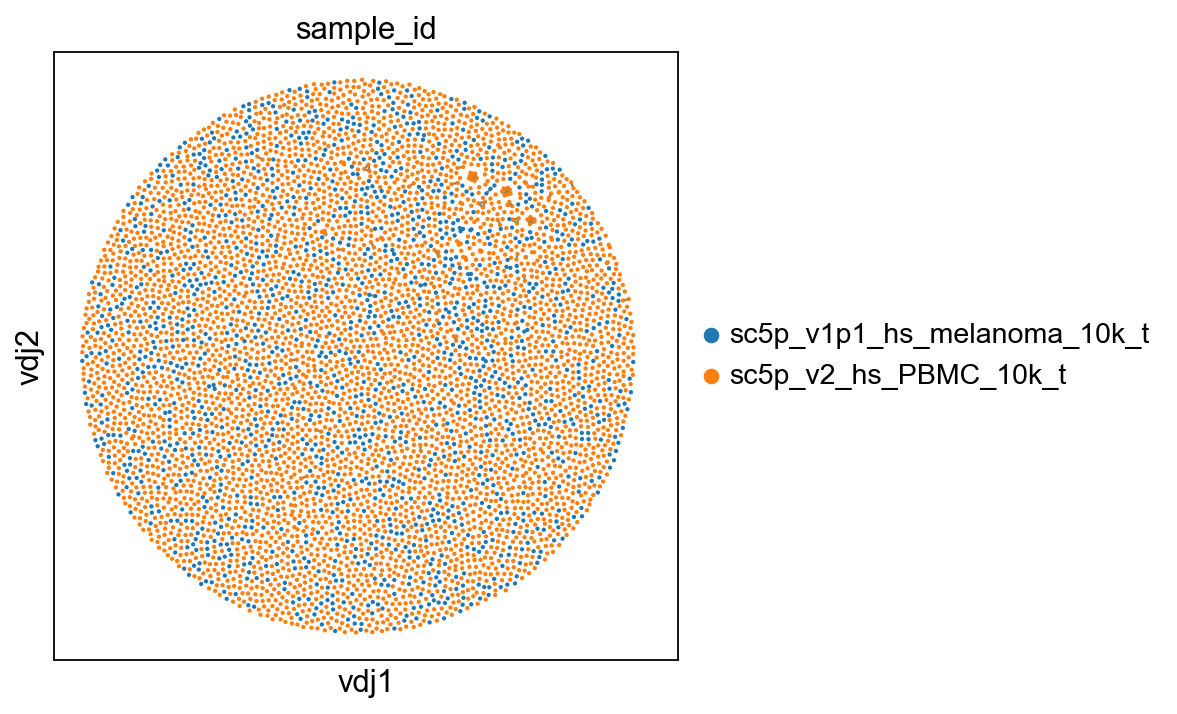

In [25]:
sc.set_figure_params(figsize=[5, 5])
ddl.pl.clone_network(adata, color=["sample_id"], edges_width=1, size=15)

In [26]:
adata

AnnData object with n_obs × n_vars = 17275 × 2305
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'leiden', 'clone_id', 'clone_id_rank'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions',

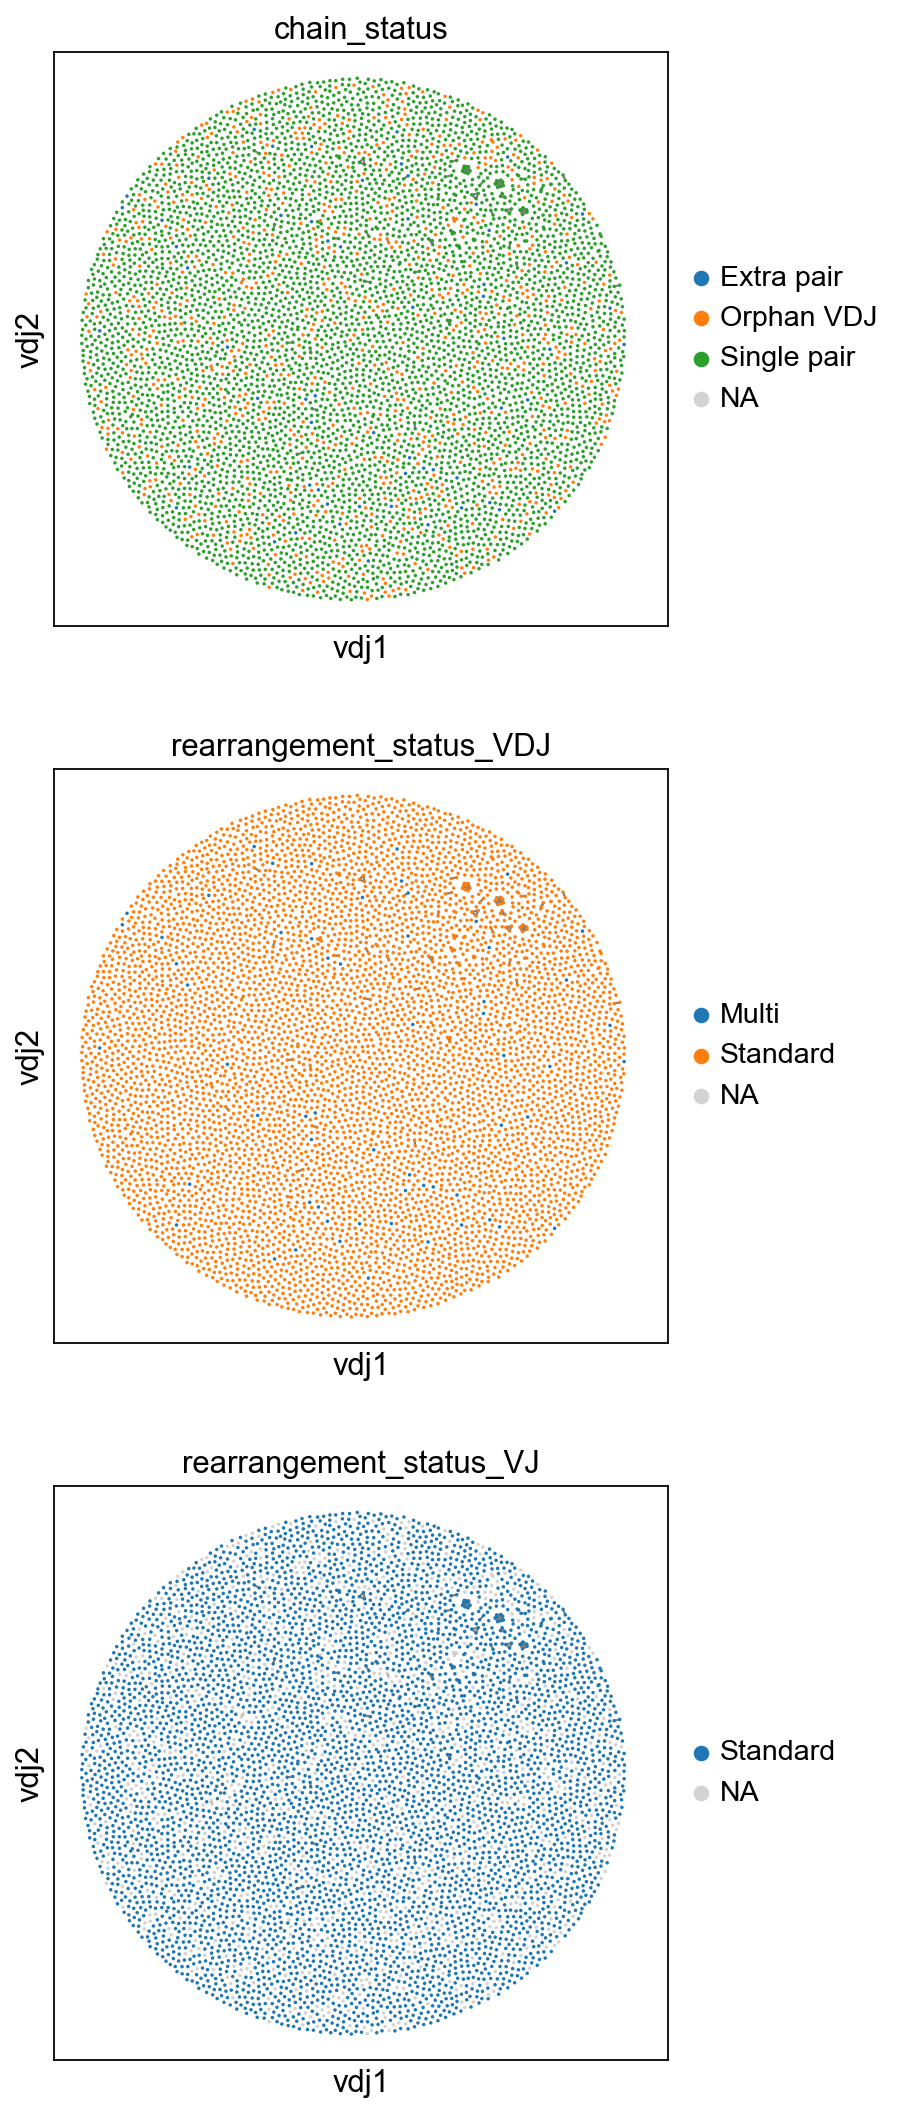

In [27]:
sc.set_figure_params(figsize=[4.5, 5])
ddl.pl.clone_network(
    adata,
    color=[
        "chain_status",
        "rearrangement_status_VDJ",
        "rearrangement_status_VJ",
    ],
    ncols=1,
    legend_fontoutline=3,
    size=10,
    edges_width=1,
)

In [28]:
ddl.tl.transfer(adata, vdj)
adata

AnnData object with n_obs × n_vars = 17275 × 2305
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'leiden', 'clone_id', 'clone_id_rank'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions',

... storing 'productive_VDJ' as categorical
... storing 'productive_VJ' as categorical
... storing 'v_call_VDJ' as categorical
... storing 'v_call_VJ' as categorical
... storing 'd_call_VDJ' as categorical
... storing 'j_call_VDJ' as categorical
... storing 'j_call_VJ' as categorical
... storing 'c_call_VDJ' as categorical
... storing 'c_call_VJ' as categorical
... storing 'junction_VDJ' as categorical
... storing 'junction_VJ' as categorical
... storing 'junction_aa_VDJ' as categorical
... storing 'junction_aa_VJ' as categorical
... storing 'locus_VDJ' as categorical
... storing 'locus_VJ' as categorical
... storing 'productive_VDJ_main' as categorical
... storing 'productive_VJ_main' as categorical
... storing 'v_call_VDJ_main' as categorical
... storing 'v_call_VJ_main' as categorical
... storing 'd_call_VDJ_main' as categorical
... storing 'j_call_VDJ_main' as categorical
... storing 'j_call_VJ_main' as categorical
... storing 'c_call_VDJ_main' as categorical
... storing 'c_call_VJ

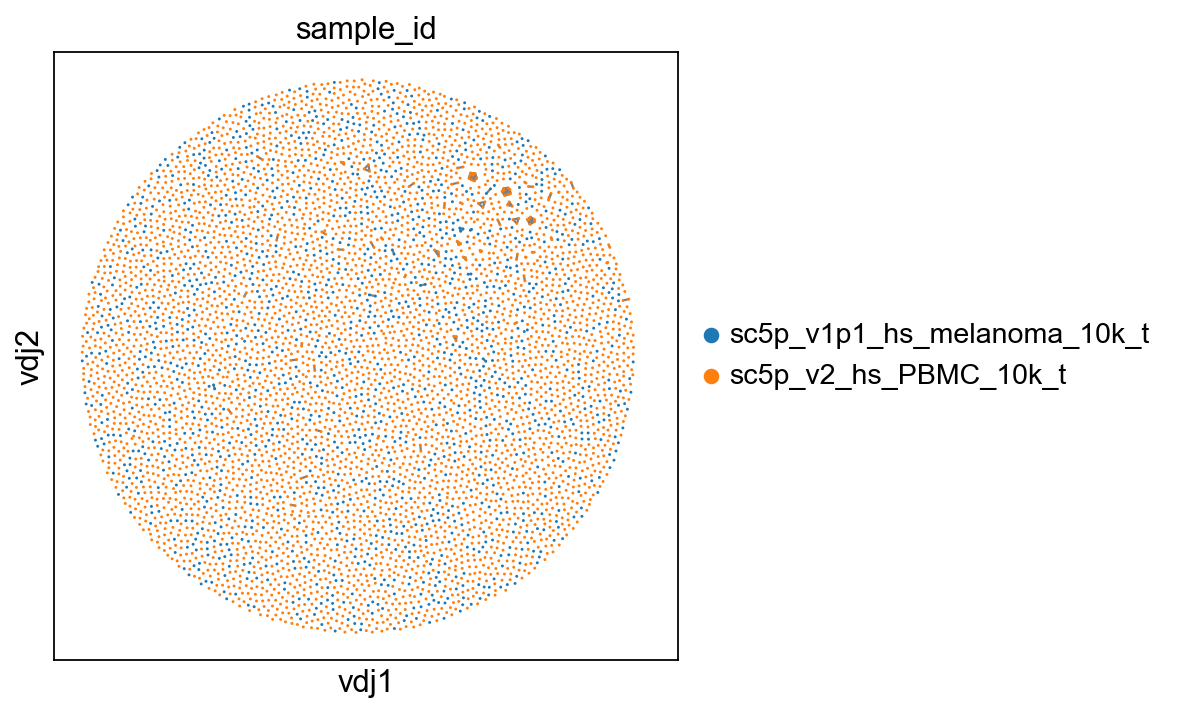

In [29]:
sc.set_figure_params(figsize=[5, 5])
ddl.pl.clone_network(adata, color=["sample_id"], edges_width=1)

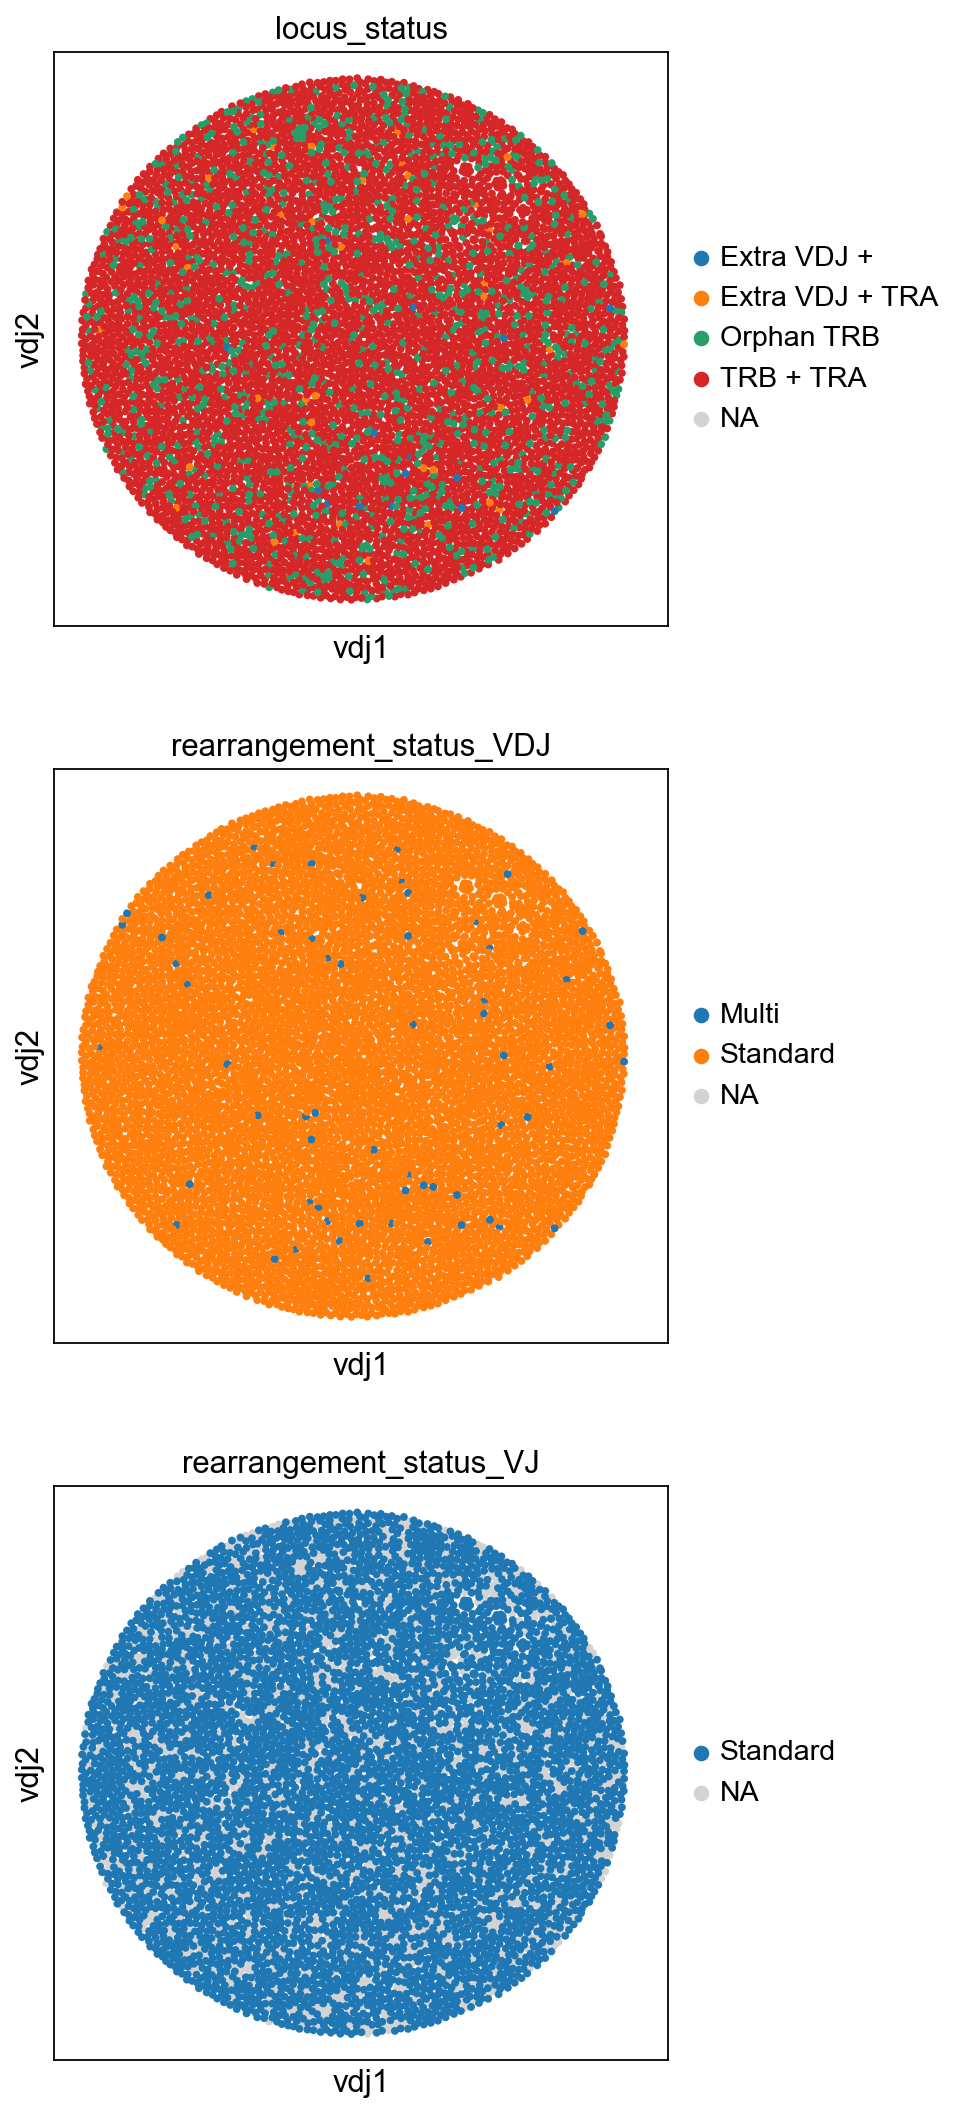

In [30]:
sc.set_figure_params(figsize=[4.5, 5])
ddl.pl.clone_network(
    adata,
    color=[
        "locus_status",
        "rearrangement_status_VDJ",
        "rearrangement_status_VJ",
    ],
    ncols=1,
    legend_fontoutline=3,
    edges_width=1,
    size=50,
)

### Using `scirpy` to plot
You can also use `scirpy`'s functions to plot the network. 

A likely use case is if you have a lot of cells and you don't want to wait for `dandelion` to generate the layout because it's taking too long. Or you simply prefer scirpy's style of plotting.

You can run `ddl.tl.generate_network(..., compute_graph = False)` and it will skip the graph construction and layout computation, and after transfer to `scirpy`, you can use its plotting functions to visualise the networks - the clone network is generated very quickly but visualising it using spring layout does take quite a while.

To access `scirpy`'s functions, you would first need to do a `Dandelion` to `scirpy` conversion first with `ddl.to_scirpy(...)`.

In [31]:
import scirpy as ir

iradata = ddl.tl.to_scirpy(vdj, gex_adata=adata, transfer=True)
iradata

MuData object with n_obs × n_vars = 17275 × 2305
  2 modalities
    gex:	17275 x 2305
      obs:	'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'leiden', 'clone_id', 'clone_id_rank'
      var:	'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'sample_id_colors', 'leiden_colors', 'chain_status_colors', 'dandelion', 'gex_neighbors', 'clone_id', 'rearrangement_status_VDJ_colors', 'rearrangement_status_VJ_colors', 'locus_status_colors'
      obsm:	'X_pca', 'X_umap', 'X_vdj'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	6094 x 0
      obs:	'clone_id', 'clone_id_rank', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ'
      uns:	'clone_id', 'dandelion', 'neighbors'
      obsm:	'airr', 'X_vdj'
      obsp:	'connectivities', 'distances'

In [32]:
iradata["airr"].uns["clone_id"]["distances"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 338 stored elements and shape (6094, 6094)>

In [33]:
from scipy.sparse import csr_matrix

isinstance(iradata["airr"].uns["clone_id"]["distances"], csr_matrix)

True

In [34]:
iradata["airr"].uns["clone_id"]["distances"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 338 stored elements and shape (6094, 6094)>

... storing 'clone_id' as categorical
... storing 'productive_VDJ' as categorical
... storing 'productive_VJ' as categorical
... storing 'v_call_VDJ' as categorical
... storing 'v_call_VJ' as categorical
... storing 'd_call_VDJ' as categorical
... storing 'j_call_VDJ' as categorical
... storing 'j_call_VJ' as categorical
... storing 'c_call_VDJ' as categorical
... storing 'c_call_VJ' as categorical
... storing 'junction_VDJ' as categorical
... storing 'junction_VJ' as categorical
... storing 'junction_aa_VDJ' as categorical
... storing 'junction_aa_VJ' as categorical
... storing 'locus_VDJ' as categorical
... storing 'locus_VJ' as categorical
... storing 'productive_VDJ_main' as categorical
... storing 'productive_VJ_main' as categorical
... storing 'v_call_VDJ_main' as categorical
... storing 'v_call_VJ_main' as categorical
... storing 'd_call_VDJ_main' as categorical
... storing 'j_call_VDJ_main' as categorical
... storing 'j_call_VJ_main' as categorical
... storing 'c_call_VDJ_main'

<Axes: >

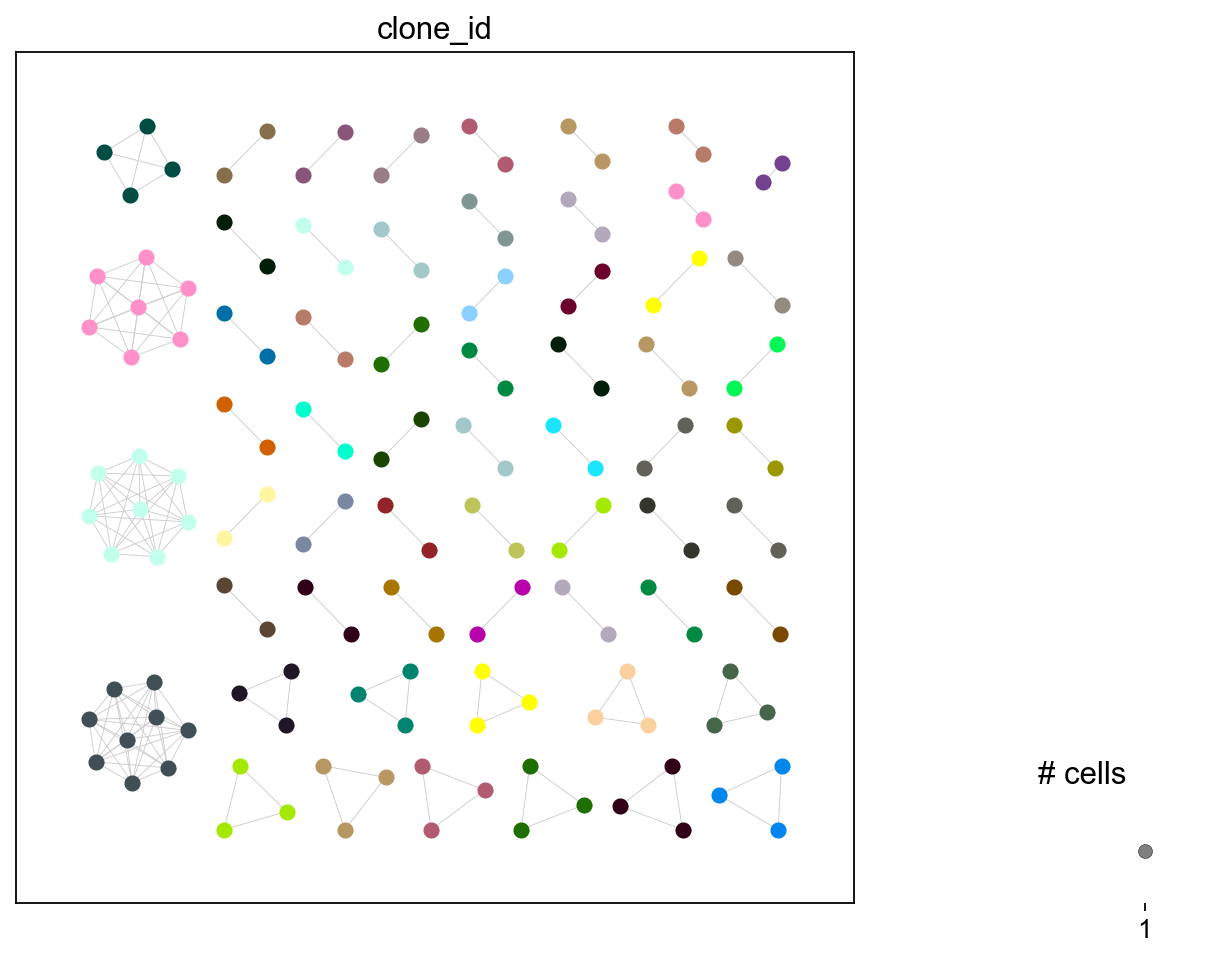

In [35]:
ir.tl.clonotype_network(iradata, min_cells=2)
ir.pl.clonotype_network(
    iradata, color="clone_id", panel_size=(7, 7), show_labels=False
)

You can change the clonotype labels by transferring with a different `clone_key`. For example, using `clone_id_rank` which is numerically ordered from largest to smallest in ascending order where 1 is the largest clone and so on.

... storing 'clone_id' as categorical
... storing 'productive_VDJ' as categorical
... storing 'productive_VJ' as categorical
... storing 'v_call_VDJ' as categorical
... storing 'v_call_VJ' as categorical
... storing 'd_call_VDJ' as categorical
... storing 'j_call_VDJ' as categorical
... storing 'j_call_VJ' as categorical
... storing 'c_call_VDJ' as categorical
... storing 'c_call_VJ' as categorical
... storing 'junction_VDJ' as categorical
... storing 'junction_VJ' as categorical
... storing 'junction_aa_VDJ' as categorical
... storing 'junction_aa_VJ' as categorical
... storing 'locus_VDJ' as categorical
... storing 'locus_VJ' as categorical
... storing 'productive_VDJ_main' as categorical
... storing 'productive_VJ_main' as categorical
... storing 'v_call_VDJ_main' as categorical
... storing 'v_call_VJ_main' as categorical
... storing 'd_call_VDJ_main' as categorical
... storing 'j_call_VDJ_main' as categorical
... storing 'j_call_VJ_main' as categorical
... storing 'c_call_VDJ_main'

<Axes: >

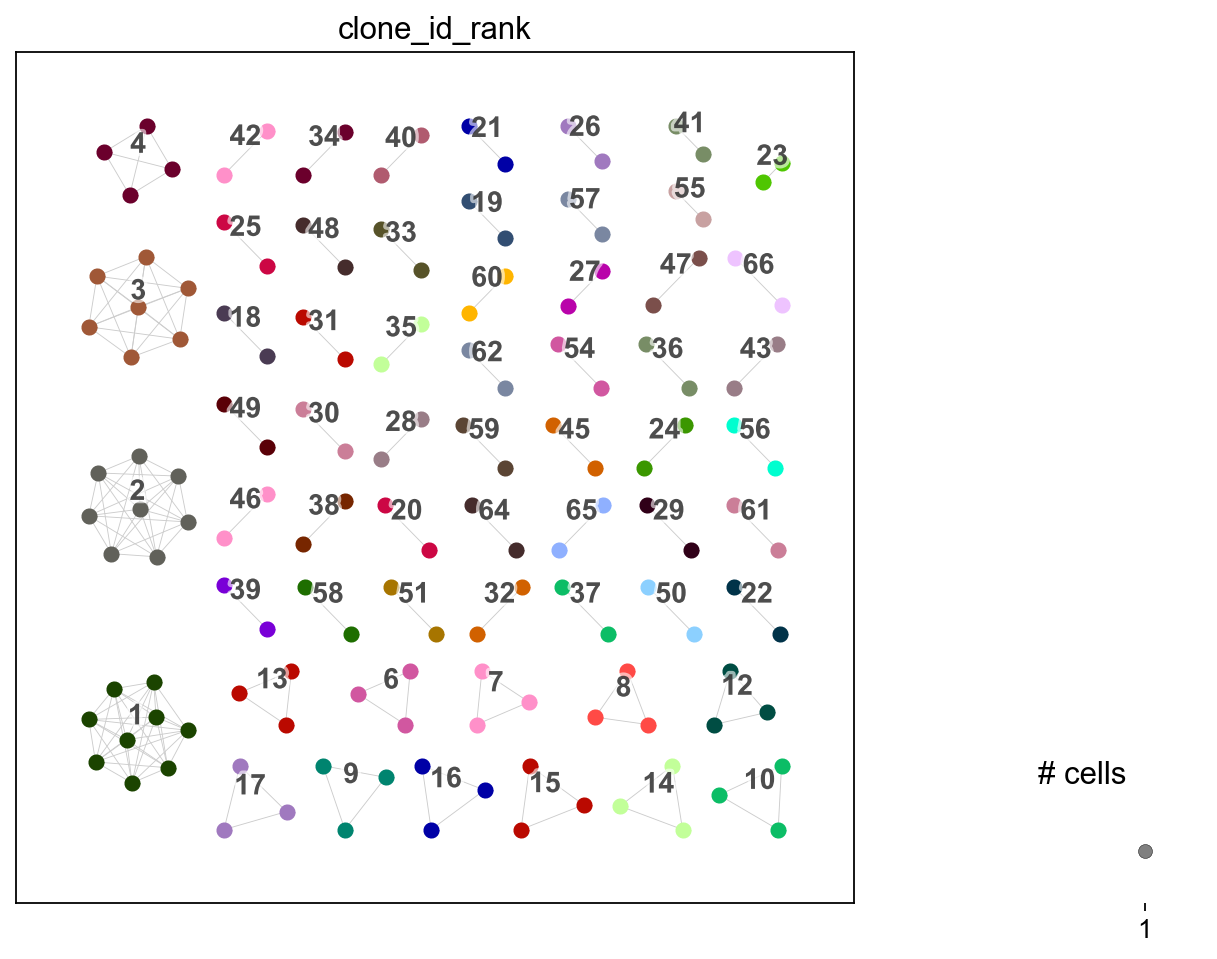

In [36]:
ddl.tl.transfer(iradata, vdj, clone_key="clone_id_rank")
ir.tl.clonotype_network(iradata, clonotype_key="clone_id_rank", min_cells=2)
ir.pl.clonotype_network(iradata, color="clone_id_rank", panel_size=(7, 7))

You can also transfer with the clones collapsed for plotting as pie-charts as per how `scirpy` does it.

... storing 'clone_id' as categorical
... storing 'productive_VDJ' as categorical
... storing 'productive_VJ' as categorical
... storing 'v_call_VDJ' as categorical
... storing 'v_call_VJ' as categorical
... storing 'd_call_VDJ' as categorical
... storing 'j_call_VDJ' as categorical
... storing 'j_call_VJ' as categorical
... storing 'c_call_VDJ' as categorical
... storing 'c_call_VJ' as categorical
... storing 'junction_VDJ' as categorical
... storing 'junction_VJ' as categorical
... storing 'junction_aa_VDJ' as categorical
... storing 'junction_aa_VJ' as categorical
... storing 'locus_VDJ' as categorical
... storing 'locus_VJ' as categorical
... storing 'productive_VDJ_main' as categorical
... storing 'productive_VJ_main' as categorical
... storing 'v_call_VDJ_main' as categorical
... storing 'v_call_VJ_main' as categorical
... storing 'd_call_VDJ_main' as categorical
... storing 'j_call_VDJ_main' as categorical
... storing 'j_call_VJ_main' as categorical
... storing 'c_call_VDJ_main'

<Axes: >

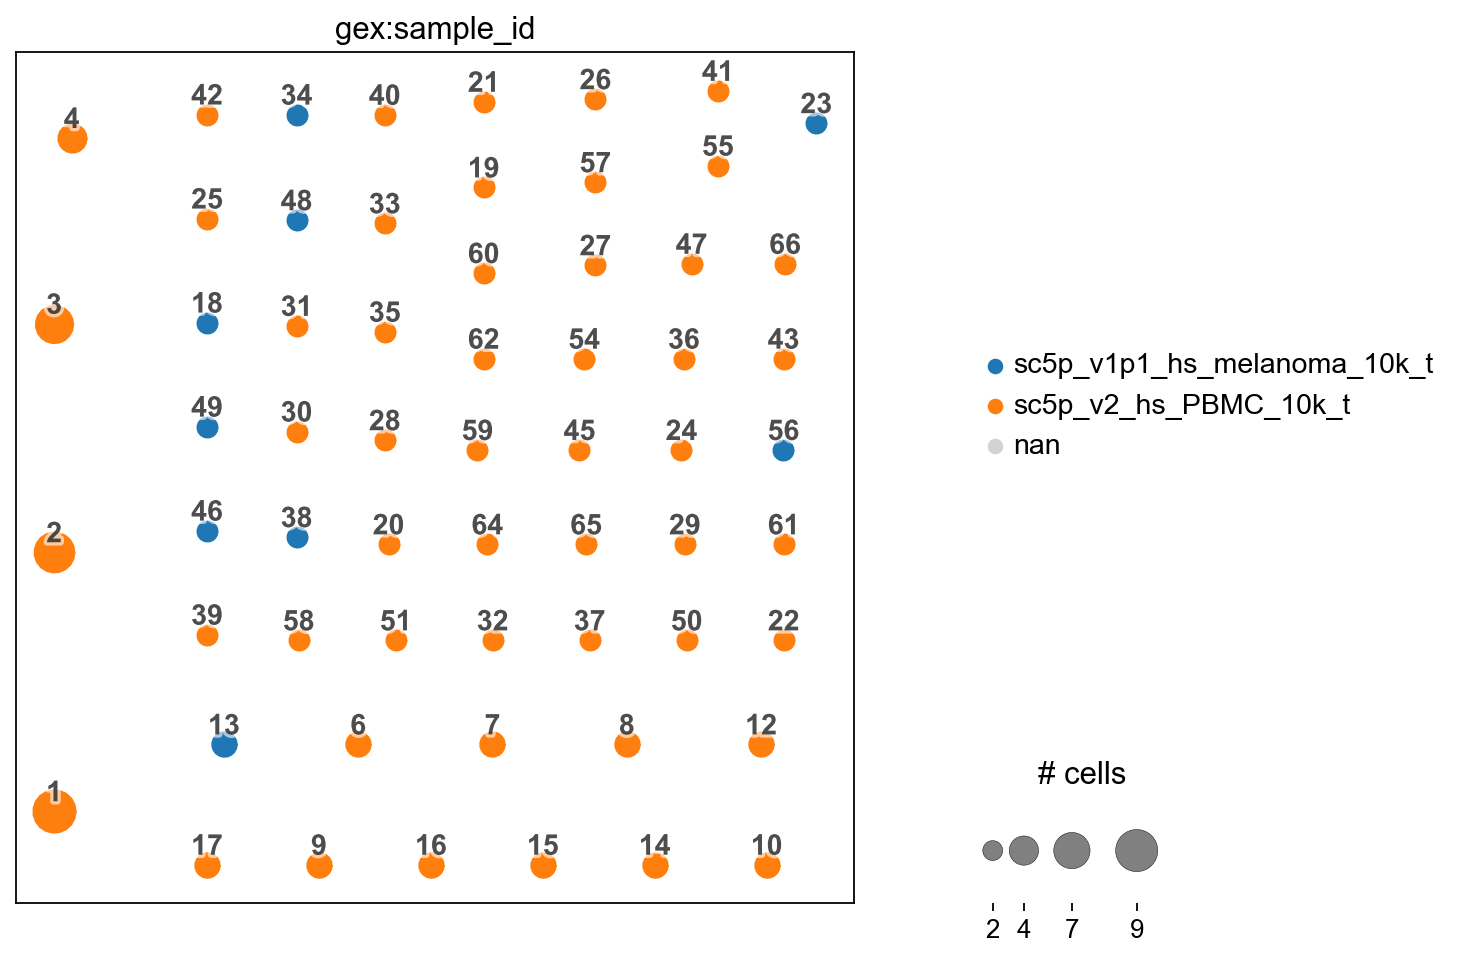

In [37]:
ddl.tl.transfer(iradata, vdj, clone_key="clone_id_rank", collapse_nodes=True)
ir.tl.clonotype_network(iradata, clonotype_key="clone_id_rank", min_cells=2)
ir.pl.clonotype_network(iradata, color="gex:sample_id", panel_size=(7, 7))

<b>Finish.</b>

We can save the files.

In [38]:
adata.write("adata_tcr.h5ad", compression="gzip")

In [39]:
vdj.write_zipddl("dandelion_results_tcr.zipddl")